# Explanation

Segmentations into gm, wm and csf regions are available from a high resolution image (144, 192, 192), saved as .nii files:
 - Segmentations/magnitude_resamToCsi_bet_pve_0.nii (this is gm)
 - Segmentations/magnitude_resamToCsi_bet_pve_1.nii (this is wm)
 - Segmentations/magnitude_resamToCsi_bet_pve_2.nii (this is csf)

I want to interpolate that to the grid used for the DMI Data of shape (22, 22, 21). The correct physical positions of the voxels
in either case are saved in the affine matrix of pve_i.nii files, or the mask in .nii format of the (22, 22, 21) grid. nilearn has 
an interpolation that directly takes into account the correct physical spacings to ensure appropriate results.

In [1]:
Subject_data = 'P06' # this is the only variable you need to set to determine the output files name

# Load all necessary data from Anna

In [2]:
import nibabel as nib
import numpy as np
from nilearn.image import resample_to_img

gm_path  = f"/workspace/Denoising/datasets/{Subject_data}/GM_Map_lr.nii"
wm_path  = f"/workspace/Denoising/datasets/{Subject_data}/WM_Map_lr.nii"
csf_path = f"/workspace/Denoising/datasets/{Subject_data}/CSF_Map_lr.nii"

gm_img  = nib.load(gm_path)
wm_img  = nib.load(wm_path)
csf_img = nib.load(csf_path)

gm  = gm_img.get_fdata().astype(np.float32)   # (22,22,21)
wm  = wm_img.get_fdata().astype(np.float32)   # (22,22,21)
csf = csf_img.get_fdata().astype(np.float32)  # (22,22,21)

# Optional: Maske laden (falls du sie weiter brauchst)
mask = nib.load(f"/workspace/Denoising/datasets/{Subject_data}/mask.nii").get_fdata().astype(np.float32)   # (22,22,21)
print("Mask shape:", mask.shape)

mask_csi = np.load(f'../datasets/{Subject_data}/mask.npy') 

stacked_low = np.stack([gm, wm, csf], axis=-1)  # (22,22,21,3)

print("GM/WM/CSF shapes:", gm.shape, wm.shape, csf.shape)
print("Low-res stacked shape:", stacked_low.shape)

Mask shape: (22, 22, 21)
GM/WM/CSF shapes: (22, 22, 21) (22, 22, 21) (22, 22, 21)
Low-res stacked shape: (22, 22, 21, 3)


# Visualize sum of wm, gm, csf and compare to mask

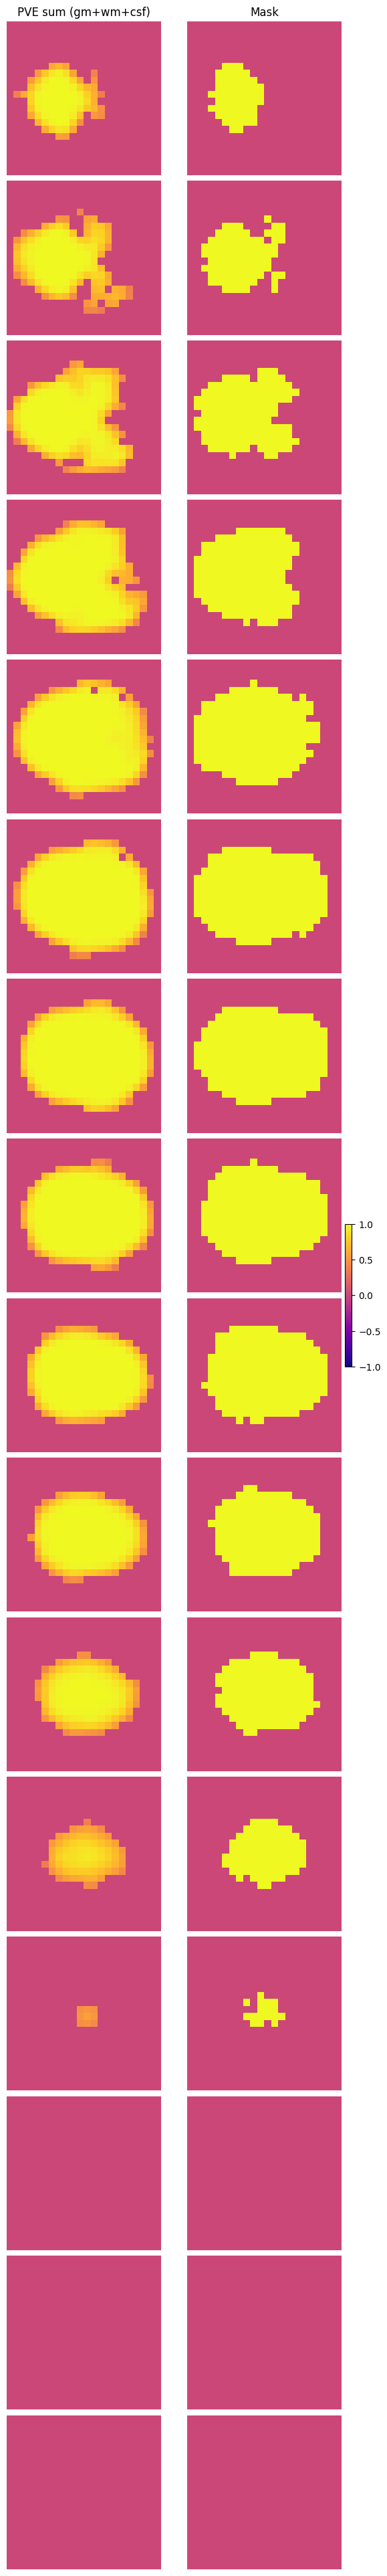

In [3]:
import matplotlib.pyplot as plt
import numpy as np

z_start, z_end = 5, 20
n_slices = z_end - z_start + 1

pve_sum = gm + wm + csf

vmin = -1
vmax = 1

fig, axes = plt.subplots(nrows=n_slices, ncols=2, figsize=(6, 2.4*n_slices), constrained_layout=True)

for row, z in enumerate(range(z_start, z_end + 1)):
    im0 = axes[row, 0].imshow(pve_sum[..., z], cmap="plasma", vmin=vmin, vmax=vmax)
    im1 = axes[row, 1].imshow(mask[..., z], cmap="plasma", vmin=vmin, vmax=vmax)

    if row == 0:
        axes[row, 0].set_title("PVE sum (gm+wm+csf)")
        axes[row, 1].set_title("Mask")

    axes[row, 0].axis("off")
    axes[row, 1].axis("off")

fig.colorbar(im0, ax=axes, fraction=0.02, pad=0.01)
plt.show()


# Invert axes to ensure orientation matches the CombinedCSI.mat orientation (saved in mask.npy)

stacked_low shape: (22, 22, 21, 3)
mask shape: (22, 22, 21)
mask_csi shape: (22, 22, 21)


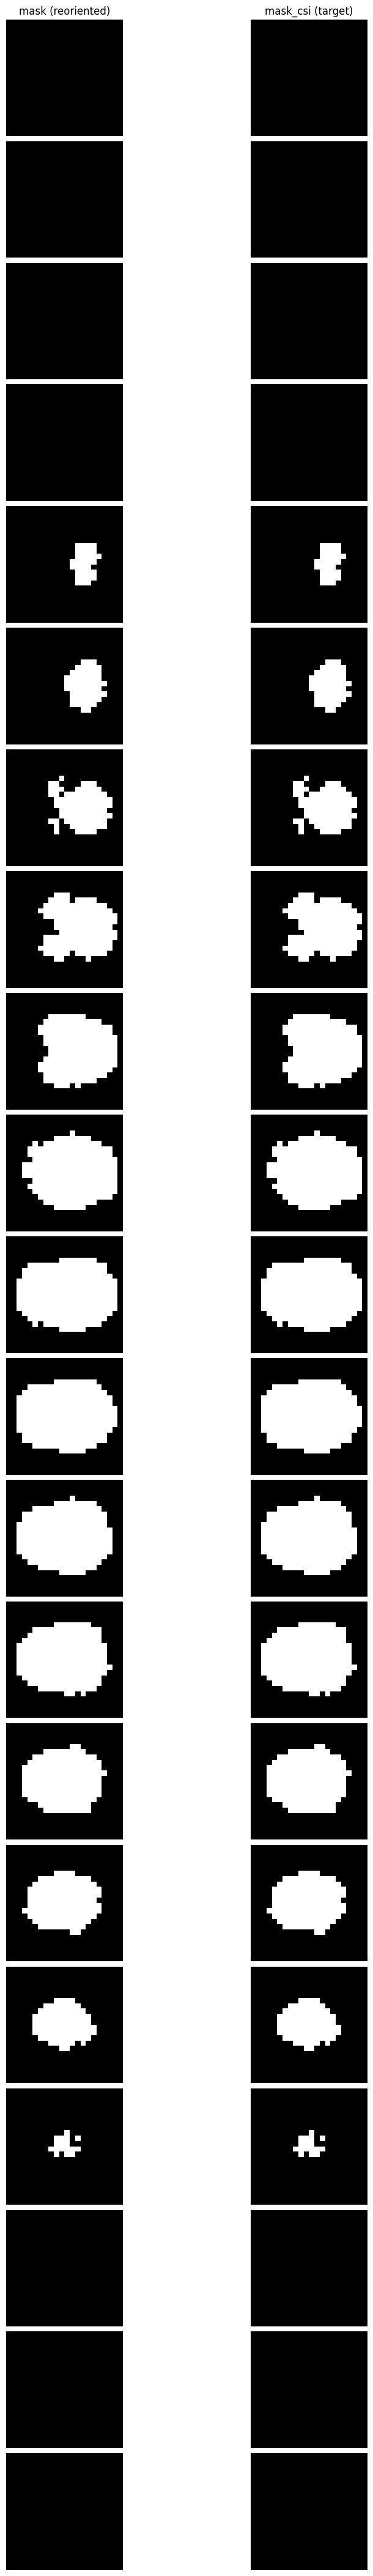

Dice(mask, mask_csi): 1.0000
Voxel mismatch count: 0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("stacked_low shape:", stacked_low.shape)
print("mask shape:", mask.shape)
print("mask_csi shape:", mask_csi.shape)

# ------------------------------------------------------------
# Reorientierung: flip x und y
# (GENAU wie in deinem ursprünglichen Code)
# ------------------------------------------------------------
stacked_low = stacked_low[::-1, ::-1, :, :]   # (22,22,21,3)
mask        = mask[::-1, ::-1, :]             # (22,22,21)

# ------------------------------------------------------------
# Vergleich: mask (reorientiert) vs mask_csi
# ------------------------------------------------------------
n_slices = mask.shape[2]

fig, axes = plt.subplots(
    nrows=n_slices,
    ncols=2,
    figsize=(8, 2.0 * n_slices),
    constrained_layout=True
)

for z in range(n_slices):
    axes[z, 0].imshow(mask[:, :, z], cmap="gray", origin="lower")
    axes[z, 0].set_title("mask (reoriented)" if z == 0 else "")
    axes[z, 0].axis("off")

    axes[z, 1].imshow(mask_csi[:, :, z], cmap="gray", origin="lower")
    axes[z, 1].set_title("mask_csi (target)" if z == 0 else "")
    axes[z, 1].axis("off")

plt.show()

# ------------------------------------------------------------
# Quantitativer Check
# ------------------------------------------------------------
mask_bin = mask > 0.5
csi_bin  = mask_csi > 0.5

dice = 2.0 * np.sum(mask_bin & csi_bin) / (np.sum(mask_bin) + np.sum(csi_bin) + 1e-8)

print(f"Dice(mask, mask_csi): {dice:.4f}")
print("Voxel mismatch count:", np.sum(mask_bin != csi_bin))

# Mask consistently and make final comparison

Note that the mask_csi for CombinedCSI.mat was very "generous" it cut away too much. For the segmentation in the final step I cut away everything outside 
the strict mask_csi to make sure that outside this mask there is no gm, wm, csf (the strict mask is used by lcmodel)

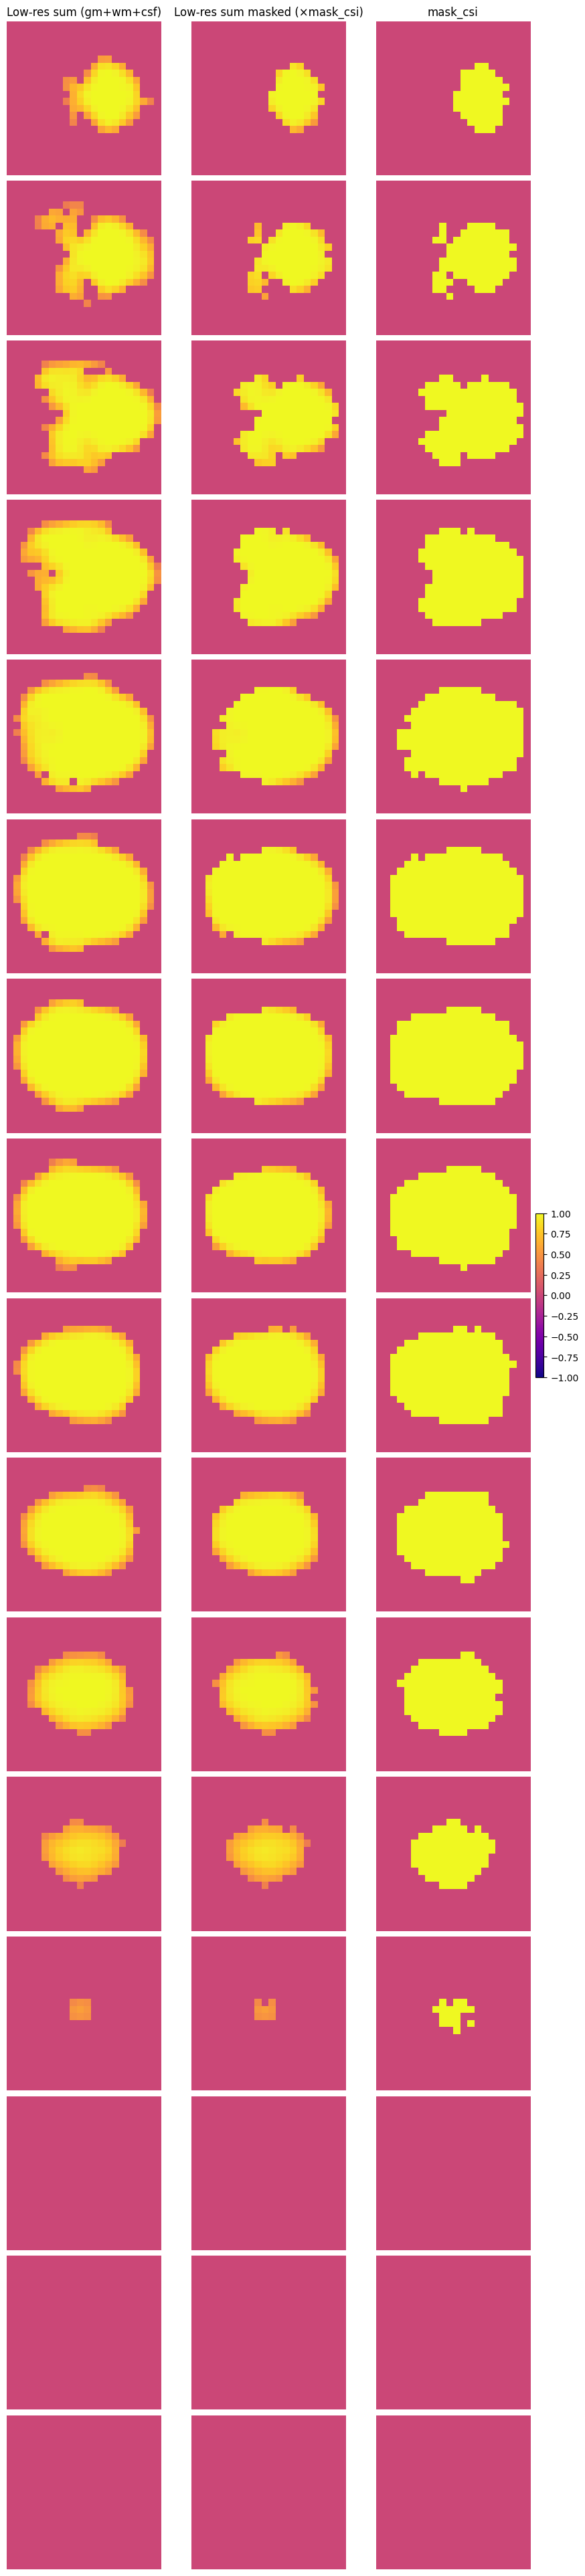

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Erwartet:
# stacked_low: (22,22,21,3)  (bereits reorientiert wie in der vorherigen Zelle)
# mask_csi:    (22,22,21)    (target)
# Optional: mask (falls du noch brauchst) wird hier nicht verwendet

# Masking der Segmentierung im Zielraster (keine neuen Namen, wir überschreiben nicht stacked_low!)
stacked_low_flipped_masked = stacked_low * mask_csi[..., np.newaxis]  # (22,22,21,3)

z_start, z_end = 5, 20
n_slices = z_end - z_start + 1

# Summenbilder
lo_sum = np.abs(np.sum(stacked_low, axis=-1))                 # (22,22,21)
lo_sum_masked = np.abs(np.sum(stacked_low_flipped_masked, axis=-1))  # (22,22,21)
msk = mask_csi                                                # (22,22,21)

# Gemeinsame Skala aus allen geplotteten Arrays
all_vals = []
for z in range(z_start, z_end + 1):
    all_vals.extend([lo_sum[..., z], lo_sum_masked[..., z], msk[..., z]])

vmin = -1
vmax = 1

# Plot: 3 Spalten = (low-res sum), (low-res sum masked), (mask_csi)
fig, axes = plt.subplots(nrows=n_slices, ncols=3, figsize=(9, 2.4 * n_slices), constrained_layout=True)

for row, z in enumerate(range(z_start, z_end + 1)):
    slice_lo        = lo_sum[..., z]
    slice_lo_masked = lo_sum_masked[..., z]
    slice_mask      = msk[..., z]

    im0 = axes[row, 0].imshow(slice_lo, cmap='plasma', vmin=vmin, vmax=vmax)
    im1 = axes[row, 1].imshow(slice_lo_masked, cmap='plasma', vmin=vmin, vmax=vmax)
    im2 = axes[row, 2].imshow(slice_mask, cmap='plasma', vmin=vmin, vmax=vmax)

    if row == 0:
        axes[row, 0].set_title('Low-res sum (gm+wm+csf)')
        axes[row, 1].set_title('Low-res sum masked (×mask_csi)')
        axes[row, 2].set_title('mask_csi')

    for ax in axes[row]:
        ax.axis('off')

fig.colorbar(im0, ax=axes, fraction=0.015, pad=0.01)
plt.show()


# Save interpolated and correctly oriented segmentations

In [ ]:
#np.save(f'../datasets/{Subject_data}/gm_wm_csf_segmentation.npy', stacked_low_flipped_masked)